# ALSRS — Hurdle (two-stage) model for zero-inflated deficit

## Motivation

The target `future_deficit_*` is **zero-inflated**: about 73% of the 1-month
values are exactly 0 (see the check below). A single `RandomForestRegressor`
has to learn two things at once: *"will there be a deficit?"* and *"how much?"*.

The literature-standard fix for semicontinuous targets is the **hurdle model**
(Cragg 1971; Mullahy 1986; Lambert 1992), also called a two-part model:

1. **Stage 1 — classifier**: `P(deficit > threshold)` (binary: 0 vs >0).
2. **Stage 2 — regressor**: trained ONLY on the rows with `deficit > threshold`,
   predicting the magnitude *given that there is a deficit*.

Final point estimate = `P(deficit>0) * E[deficit | deficit>0]`.

## What this notebook does

- Inspects the zero-inflation of each horizon.
- Implements the two stages as clean, documented functions.
- Compares **hurdle vs single-RF** on the SAME 5-fold CV by farm (fair A/B).
- Shows decision-level recall (HIGH / NOT_SUITABLE) on a holdout.
- Checks whether the hurdle actually fixes the zero rows.


In [1]:
# -----------------------------------------------------------------------------
# 1. Imports
# -----------------------------------------------------------------------------
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Random Forest (regression + classification), split and metrics.
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
    precision_recall_fscore_support,
)

print("pandas", pd.__version__, "| numpy", np.__version__)


pandas 2.3.3 | numpy 2.2.6


In [2]:
# -----------------------------------------------------------------------------
# 2. Dataset + schema
# -----------------------------------------------------------------------------
# The notebook lives in ml/; resolve that directory robustly.
ML_DIR = Path.cwd() if Path.cwd().name == "ml" else Path.cwd() / "ml"
DATASET = ML_DIR / "ml_dataset_cacao_ccn51.csv"

df = pd.read_csv(DATASET)
print("Dataset:", DATASET.name, f"({df.shape[0]} rows x {df.shape[1]} cols)")
print("Farms (point_id):", df["point_id"].nunique())

# Features: variables known AT time t only (no future information is leaked).
FEATURES = [
    "month", "biweek",
    "mean_C", "std_C",
    "precip_total_mm", "precip_rainy_days", "pet_mm",
    "spei_1m", "spei_3m", "spei_6m", "spei_12m",
    "AWC_mm", "Storage_mm", "P_acum_mm",
    "WRSI_1m", "deficit_1m",
    "oni",
]

# Targets: deficit accumulated over the NEXT 1 / 3 / 6 months (0-100%).
TARGETS = ["future_deficit_1m", "future_deficit_3m", "future_deficit_6m"]

# Irrigation-need classes (thresholds 15 / 30 / 50).
SEVERITY = {"LOW": 0, "MEDIUM": 1, "HIGH": 2, "NOT_SUITABLE": 3}

# Hurdle threshold: what counts as "there is a deficit".
# 0.0 -> classic hurdle (0 vs >0). Change to 15.0 to mean "needs irrigation".
DEFICIT_THRESHOLD = 0.0

# Same FINAL configuration used by the single-RF model (experiments A + B).
REGRESSOR_CONFIG = dict(n_estimators=300, max_depth=None, min_samples_leaf=1,
                        random_state=42, n_jobs=-1)

# Classifier config: same forest, but balanced class weights because the
# positive class is a minority at short horizons (~27% for 1 month).
CLASSIFIER_CONFIG = dict(n_estimators=300, max_depth=None, min_samples_leaf=1,
                         class_weight="balanced", random_state=42, n_jobs=-1)


Dataset: ml_dataset_cacao_ccn51.csv (52341 rows x 33 cols)
Farms (point_id): 239


## 3. How zero-inflated is the target?

Fraction of exactly-zero rows, positive rows, and the tail of the distribution
for each horizon. This tells us where the hurdle should help the most: the more
zeros, the more the single model wastes capacity predicting small positive
values instead of exactly 0.


In [3]:
# -----------------------------------------------------------------------------
# 3. Zero-inflation inspection
# -----------------------------------------------------------------------------
for target in TARGETS:
    s = df[target]
    n_pos = int((s > DEFICIT_THRESHOLD).sum())
    print(f"{target:<22s} zeros={(s == 0).mean()*100:5.1f}%  "
          f">0={(s > 0).mean()*100:5.1f}%  (n={n_pos:6d})  "
          f"median={s.median():5.2f}  max={s.max():6.2f}")


future_deficit_1m      zeros= 72.8%  >0= 27.2%  (n= 14258)  median= 0.00  max=100.00
future_deficit_3m      zeros= 56.4%  >0= 43.6%  (n= 22820)  median= 0.00  max=100.00
future_deficit_6m      zeros= 39.2%  >0= 60.8%  (n= 31845)  median= 5.67  max= 88.84


## 4. The hurdle (two-stage) model

**Stage 1 (classifier)** answers "is there a deficit?" -> `P(deficit > threshold)`.
**Stage 2 (regressor)** answers "given that there is a deficit, how much?", and
is trained **only on positive rows** so it never wastes capacity on zeros.

Combined point estimate (the unconditional expectation):

    expected = P(deficit > 0) * E[deficit | deficit > 0]

We compare this `expected` against the single-RF prediction on the same folds.


In [4]:
# -----------------------------------------------------------------------------
# 4. Helpers + the two stages
# -----------------------------------------------------------------------------
def weight_linear(deficit):
    """weight = deficit: zero-deficit rows contribute nothing, the tail dominates."""
    return deficit


def rmse(y_true, y_pred):
    """Root mean squared error (same units as the deficit, percentage points)."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def classify_deficit(v):
    """Map a deficit percentage to its irrigation-need class (thresholds 15/30/50)."""
    if pd.isna(v):
        return "NA"
    if v <= 15:
        return "LOW"
    if v <= 30:
        return "MEDIUM"
    if v <= 50:
        return "HIGH"
    return "NOT_SUITABLE"


def worst_of(*classes):
    """Most severe class among the 3 horizons (the final irrigation suggestion)."""
    return max(classes, key=lambda c: SEVERITY.get(c, -1))


def make_regressor():
    """Fresh RandomForestRegressor with the FINAL recommended configuration."""
    return RandomForestRegressor(**REGRESSOR_CONFIG)


def make_classifier():
    """Fresh RandomForestClassifier with balanced class weights for the hurdle."""
    return RandomForestClassifier(**CLASSIFIER_CONFIG)


def hurdle_fit_predict(Xtr, ytr, Xva, threshold=0.0):
    """Fit the two stages and return predictions for the validation rows.

    Parameters
    ----------
    Xtr, ytr : training features and continuous target (numpy arrays).
    Xva      : validation features (numpy array).
    threshold: deficit above which a row counts as positive.

    Returns
    -------
    p_pos    : P(deficit > threshold) from the stage-1 classifier.
    mu_pos   : E[deficit | deficit > threshold] from the stage-2 regressor.
    expected : p_pos * mu_pos  (unconditional expected deficit).
    """
    # ---- Stage 1: classifier (0 vs >threshold) on ALL rows ----
    ytr_bin = (ytr > threshold).astype(int)
    clf = make_classifier()
    clf.fit(Xtr, ytr_bin)
    p_pos = clf.predict_proba(Xva)[:, 1]

    # ---- Stage 2: regressor on POSITIVE rows only ----
    pos_rows = ytr > threshold
    if pos_rows.sum() == 0:
        # Degenerate fold: no positive rows to learn from -> predict 0 magnitude.
        mu_pos = np.zeros(len(Xva))
    else:
        reg = make_regressor()
        reg.fit(Xtr[pos_rows], ytr[pos_rows],
                sample_weight=weight_linear(ytr[pos_rows]))
        mu_pos = reg.predict(Xva)

    expected = p_pos * mu_pos
    return p_pos, mu_pos, expected


def gated_prediction(p_pos, mu_pos, prob_threshold=0.5):
    """Decision-oriented combination of the two stages.

    Unlike expected = p_pos * mu_pos (which shrinks the magnitude by P>0),
    this uses stage 1 only as a gate: if P(deficit > threshold) is high
    enough we keep the FULL stage-2 magnitude; otherwise we predict 0.

    The expected value is the right point estimate for MAE/RMSE, but it
    shrinks the tail and downgrades HIGH / NOT_SUITABLE, so for the
    irrigation DECISION the gated combination is the correct one.
    """
    return np.where(p_pos >= prob_threshold, mu_pos, 0.0)


def baseline_fit_predict(Xtr, ytr, Xva):
    """The current single-RF approach (for the A/B comparison).

    One RandomForestRegressor on ALL rows with sample_weight = linear(deficit).
    """
    model = make_regressor()
    model.fit(Xtr, ytr, sample_weight=weight_linear(ytr))
    return model.predict(Xva)


## 5. A/B comparison — same 5-fold CV by farm

For each horizon we run `GroupKFold(5)` grouped by `point_id` (a farm is never
split between train and test). On every fold we fit BOTH approaches and record:

- **baseline**: single RF -> MAE / RMSE over all rows.
- **hurdle**: two stages -> `expected` -> MAE / RMSE over all rows.
- **stage 1**: AUC, precision / recall / F1 of the "has deficit" class.
- **stage 2**: MAE / RMSE over the **positive** rows only.


In [5]:
# -----------------------------------------------------------------------------
# 5. Cross-validated comparison (single-RF vs hurdle)
# -----------------------------------------------------------------------------
def cv_compare(target, threshold=0.0, n_splits=5):
    """Fair A/B: single-RF vs hurdle on the same by-farm folds.

    Returns a dict with the averaged metrics described in the section above.
    """
    gkf = GroupKFold(n_splits=n_splits)
    y = df[target].to_numpy()

    base_mae, base_rmse = [], []
    hurd_mae, hurd_rmse = [], []
    s1_auc, s1_prec, s1_rec, s1_f1 = [], [], [], []
    s2_mae, s2_rmse = [], []

    for tr_idx, va_idx in gkf.split(df, groups=df["point_id"]):
        Xtr = df.iloc[tr_idx][FEATURES].to_numpy()
        Xva = df.iloc[va_idx][FEATURES].to_numpy()
        ytr = y[tr_idx]
        yva = y[va_idx]

        # ---- baseline: single RF ----
        base_pred = baseline_fit_predict(Xtr, ytr, Xva)
        base_mae.append(mean_absolute_error(yva, base_pred))
        base_rmse.append(rmse(yva, base_pred))

        # ---- hurdle ----
        p_pos, mu_pos, expected = hurdle_fit_predict(Xtr, ytr, Xva, threshold)

        # combined expected vs truth, all rows
        hurd_mae.append(mean_absolute_error(yva, expected))
        hurd_rmse.append(rmse(yva, expected))

        # stage 1 metrics (positive class)
        yva_bin = (yva > threshold).astype(int)
        if len(np.unique(yva_bin)) == 2:          # guard: both classes present
            s1_auc.append(roc_auc_score(yva_bin, p_pos))
        pred_bin = (p_pos >= 0.5).astype(int)
        prec, rec, f1, _ = precision_recall_fscore_support(
            yva_bin, pred_bin, average="binary", zero_division=0)
        s1_prec.append(prec); s1_rec.append(rec); s1_f1.append(f1)

        # stage 2 metrics (positive rows only)
        pos_mask = yva > threshold
        if pos_mask.sum() > 0:
            s2_mae.append(mean_absolute_error(yva[pos_mask], mu_pos[pos_mask]))
            s2_rmse.append(rmse(yva[pos_mask], mu_pos[pos_mask]))

    def avg(lst):
        return float(np.mean(lst))

    return {
        "base_mae": avg(base_mae), "base_rmse": avg(base_rmse),
        "hurd_mae": avg(hurd_mae), "hurd_rmse": avg(hurd_rmse),
        "s1_auc": avg(s1_auc), "s1_prec": avg(s1_prec),
        "s1_rec": avg(s1_rec), "s1_f1": avg(s1_f1),
        "s2_mae": avg(s2_mae), "s2_rmse": avg(s2_rmse),
    }


In [6]:
# -----------------------------------------------------------------------------
# 5b. Run the comparison for all horizons
# -----------------------------------------------------------------------------
print(f"Threshold for 'has deficit': > {DEFICIT_THRESHOLD}\n")
for target in TARGETS:
    r = cv_compare(target, threshold=DEFICIT_THRESHOLD, n_splits=5)
    print(f"{target:<22s}")
    print(f"  baseline : MAE={r['base_mae']:6.2f}  RMSE={r['base_rmse']:6.2f}")
    print(f"  hurdle   : MAE={r['hurd_mae']:6.2f}  RMSE={r['hurd_rmse']:6.2f}")
    print(f"  stage 1  : AUC={r['s1_auc']:.3f}  prec={r['s1_prec']:.3f}  "
          f"rec={r['s1_rec']:.3f}  F1={r['s1_f1']:.3f}")
    print(f"  stage 2  : MAE={r['s2_mae']:6.2f}  RMSE={r['s2_rmse']:6.2f}  "
          f"(positive rows only)")
    print()


Threshold for 'has deficit': > 0.0

future_deficit_1m     
  baseline : MAE= 11.21  RMSE= 13.81
  hurdle   : MAE=  4.73  RMSE=  9.47
  stage 1  : AUC=0.983  prec=0.897  rec=0.867  F1=0.882
  stage 2  : MAE= 11.35  RMSE= 14.67  (positive rows only)

future_deficit_3m     
  baseline : MAE= 11.00  RMSE= 12.84
  hurdle   : MAE=  5.56  RMSE=  8.80
  stage 1  : AUC=0.958  prec=0.879  rec=0.859  F1=0.869
  stage 2  : MAE=  8.26  RMSE= 10.88  (positive rows only)

future_deficit_6m     
  baseline : MAE= 10.60  RMSE= 12.76
  hurdle   : MAE=  7.52  RMSE= 10.25
  stage 1  : AUC=0.913  prec=0.832  rec=0.901  F1=0.865
  stage 2  : MAE=  8.49  RMSE= 11.09  (positive rows only)



## 6. Decision-level recall (holdout, worst-of-3)

The final `suggestion` is the **worst class across the 3 horizons**. On an
80/20 holdout we compare, for the severe classes HIGH / NOT_SUITABLE, how
often each approach catches them:

- **baseline**   : single Random Forest.
- **hurdle P*mu** : `expected = P(deficit>0) * magnitude` (the expected value).
- **hurdle gated** : stage 1 as a gate + FULL stage-2 magnitude (no shrinkage).

The gated version is the decision-correct one: `P*mu` shrinks the magnitude
and downgrades the severe classes, which is why it loses recall despite the
better MAE.


In [7]:
# Same 80/20 by-farm split as the other notebooks.
point_ids = df["point_id"].unique()
train_pts, test_pts = train_test_split(point_ids, test_size=0.20, random_state=42)
tr = df[df["point_id"].isin(train_pts)]
te = df[df["point_id"].isin(test_pts)]

Xtr_all = tr[FEATURES].to_numpy()
Xte_all = te[FEATURES].to_numpy()

# Three continuous predictions per horizon:
#   baseline     : single Random Forest.
#   hurdle P*mu  : expected = P(deficit>0) * magnitude  (shrunken tail).
#   hurdle gated : stage 1 as a gate + FULL magnitude    (decision-correct).
base_preds, hurd_preds, gated_preds = {}, {}, {}
hurd_p, hurd_mu = {}, {}
for target in TARGETS:
    ytr = tr[target].to_numpy()
    base_preds[target] = baseline_fit_predict(Xtr_all, ytr, Xte_all)
    p_pos, mu_pos, expected = hurdle_fit_predict(Xtr_all, ytr, Xte_all, DEFICIT_THRESHOLD)
    hurd_preds[target] = expected
    hurd_p[target] = p_pos
    hurd_mu[target] = mu_pos
    gated_preds[target] = gated_prediction(p_pos, mu_pos)


def to_suggestion(te, preds):
    # Convert continuous predictions (one per horizon) to the worst-of-3 class.
    cls = pd.DataFrame({t: np.asarray(preds[t]) for t in TARGETS}, index=te.index)
    cls = cls.map(classify_deficit)
    return cls.apply(lambda r: worst_of(*r), axis=1)


true_sugg = to_suggestion(te, {t: te[t].to_numpy() for t in TARGETS})
base_sugg = to_suggestion(te, base_preds)
hurd_sugg = to_suggestion(te, hurd_preds)
gated_sugg = to_suggestion(te, gated_preds)

for cls in ["MEDIUM", "HIGH", "NOT_SUITABLE"]:
    mask = true_sugg == cls
    if mask.sum() == 0:
        continue
    b = (base_sugg[mask] == cls).mean()
    h = (hurd_sugg[mask] == cls).mean()
    g = (gated_sugg[mask] == cls).mean()
    print(f"recall {cls:<13}: baseline={b:.3f}   "
          f"hurdle(P*mu)={h:.3f}   hurdle(gated)={g:.3f}")


recall MEDIUM       : baseline=0.689   hurdle(P*mu)=0.464   hurdle(gated)=0.610
recall HIGH         : baseline=0.461   hurdle(P*mu)=0.279   hurdle(gated)=0.456
recall NOT_SUITABLE : baseline=0.674   hurdle(P*mu)=0.575   hurdle(gated)=0.674


## 7. Gate threshold sweep (trade-off recall vs MAE)

The gate rule is: keep the FULL magnitude when `P(deficit>0) >=
prob_threshold`, else predict 0. The threshold controls the trade-off:

- **lower** threshold -> more `yes` decisions -> fewer missed severe cases
  (higher recall) but more false alarms (worse MAE, especially on the
  zero rows).
- **higher** threshold -> more conservative -> fewer false alarms but more
  missed severe cases.

We sweep 0.2-1.0 and watch recall of MEDIUM / HIGH / NOT_SUITABLE and MAE move.


In [8]:
# Sweep the gate threshold. No re-fitting is needed: we reuse the
# stage-1 probabilities (hurd_p) and stage-2 magnitudes (hurd_mu) from
# section 6 and just apply gated_prediction with different thresholds.
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

rows = []
for thr in thresholds:
    gated = {t: gated_prediction(hurd_p[t], hurd_mu[t], thr) for t in TARGETS}
    sugg = to_suggestion(te, gated)

    recalls = {}
    for cls in ["MEDIUM", "HIGH", "NOT_SUITABLE"]:
        mask = true_sugg == cls
        recalls[cls] = (sugg[mask] == cls).mean() if mask.sum() else float("nan")

    maes = {t: mean_absolute_error(te[t].to_numpy(), gated[t]) for t in TARGETS}
    rows.append([thr, recalls["MEDIUM"], recalls["HIGH"], recalls["NOT_SUITABLE"],
                 maes["future_deficit_1m"], maes["future_deficit_3m"],
                 maes["future_deficit_6m"]])

sweep = pd.DataFrame(rows, columns=[
    "threshold", "recall_MEDIUM", "recall_HIGH", "recall_NOT_SUITABLE",
    "mae_1m", "mae_3m", "mae_6m",
])

# Baseline (single RF) reference for the same two axes.
b_md = (base_sugg[true_sugg == "MEDIUM"] == "MEDIUM").mean()
b_high = (base_sugg[true_sugg == "HIGH"] == "HIGH").mean()
b_ns = (base_sugg[true_sugg == "NOT_SUITABLE"] == "NOT_SUITABLE").mean()
print("baseline (single RF) -> "," recall MEDIUM:", round(b_md, 3),
      " recall HIGH:", round(b_high, 3)," recall NOT_SUITABLE:", round(b_ns, 3))
print()
print(sweep.round(3).to_string(index=False))


baseline (single RF) ->   recall MEDIUM: 0.689  recall HIGH: 0.461  recall NOT_SUITABLE: 0.674

 threshold  recall_MEDIUM  recall_HIGH  recall_NOT_SUITABLE  mae_1m  mae_3m  mae_6m
       0.2          0.671        0.464                0.674   5.894   6.767   9.489
       0.3          0.657        0.464                0.674   5.133   5.858   8.769
       0.4          0.649        0.460                0.674   4.634   5.256   8.008
       0.5          0.610        0.456                0.674   4.332   4.864   7.492
       0.6          0.547        0.444                0.673   4.162   4.860   7.359
       0.7          0.453        0.399                0.670   4.401   5.310   7.689
       0.8          0.296        0.314                0.648   5.150   6.369   8.572
       0.9          0.143        0.176                0.563   7.151   8.410  10.227
       1.0          0.002        0.002                0.012  14.081  14.491  14.974


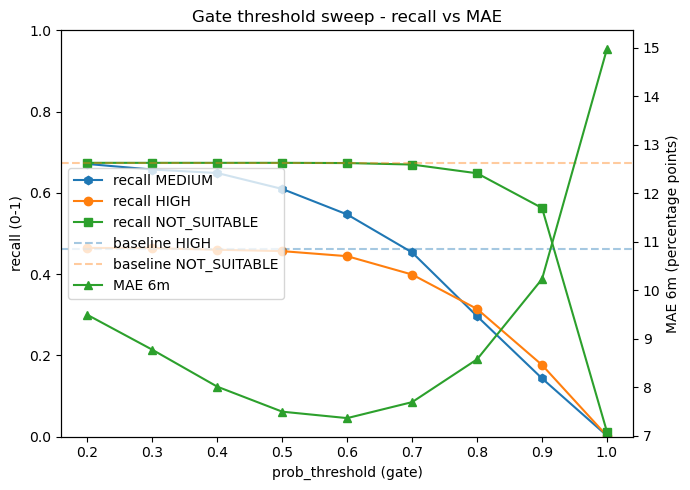

In [17]:
# Visualize the trade-off: recall (left axis) vs MAE 6m (right axis).
fig, ax1 = plt.subplots(figsize=(7, 5))
l1, = ax1.plot(sweep["threshold"], sweep["recall_MEDIUM"], "h-", label="recall MEDIUM")
l2, = ax1.plot(sweep["threshold"], sweep["recall_HIGH"], "o-", label="recall HIGH")
l3, = ax1.plot(sweep["threshold"], sweep["recall_NOT_SUITABLE"], "s-",
               label="recall NOT_SUITABLE")
l4 = ax1.axhline(b_high, ls="--", color="C0", alpha=0.4)
l5 = ax1.axhline(b_ns, ls="--", color="C1", alpha=0.4)
ax1.set_xlabel("prob_threshold (gate)")
ax1.set_ylabel("recall (0-1)")
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
l6, = ax2.plot(sweep["threshold"], sweep["mae_6m"], "^-", color="C2",
               label="MAE 6m")
ax2.set_ylabel("MAE 6m (percentage points)")

ax1.legend(handles=[l1, l2, l3, l4, l5, l6],
           labels=["recall MEDIUM", "recall HIGH", "recall NOT_SUITABLE",
                   "baseline HIGH", "baseline NOT_SUITABLE", "MAE 6m"],
           loc="center left")
plt.title("Gate threshold sweep - recall vs MAE")
plt.tight_layout()
plt.show()


## 8. Does the hurdle actually fix the zero rows?

The single RF cannot output exactly 0, so on rows where the true deficit is 0 it
predicts a small positive number, inflating MAE. Here we check, on the 1-month
holdout, the mean prediction on the TRUE-ZERO rows for both approaches.


In [18]:
# Use the 1-month horizon (the most zero-inflated: ~73% zeros).
target = "future_deficit_1m"
zero_mask = te[target].to_numpy() == 0.0

print("Rows with true 1m deficit == 0:", zero_mask.sum())
print(f"  baseline        mean on those rows : {base_preds[target][zero_mask].mean():5.2f}")
print(f"  hurdle (P*mu)   mean on those rows : {hurd_preds[target][zero_mask].mean():5.2f}")
print(f"  hurdle (gated)  mean on those rows : {gated_preds[target][zero_mask].mean():5.2f}")
print()
print("A mean close to 0 means the approach correctly says 'no deficit'.")


Rows with true 1m deficit == 0: 7244
  baseline        mean on those rows : 11.79
  hurdle (P*mu)   mean on those rows :  1.80
  hurdle (gated)  mean on those rows :  1.00

A mean close to 0 means the approach correctly says 'no deficit'.


## 9. Feature importance — what drives each stage?

Stage 1 (the "is there a deficit?" decision) and stage 2 (the "how much?"
magnitude) can rely on different features. We look at the 6-month horizon.


                   stage1_clf  stage2_reg    mean
AWC_mm                 0.0692      0.1764  0.1228
month                  0.0689      0.1490  0.1089
Storage_mm             0.1246      0.0766  0.1006
P_acum_mm              0.1349      0.0559  0.0954
mean_C                 0.0579      0.1038  0.0808
oni                    0.0865      0.0716  0.0790
pet_mm                 0.0592      0.0685  0.0639
spei_12m               0.0580      0.0556  0.0568
spei_1m                0.0563      0.0430  0.0496
spei_6m                0.0508      0.0441  0.0474
spei_3m                0.0500      0.0429  0.0464
std_C                  0.0475      0.0417  0.0446
precip_total_mm        0.0436      0.0240  0.0338
precip_rainy_days      0.0279      0.0182  0.0231
WRSI_1m                0.0309      0.0105  0.0207
deficit_1m             0.0268      0.0115  0.0191
biweek                 0.0070      0.0069  0.0070


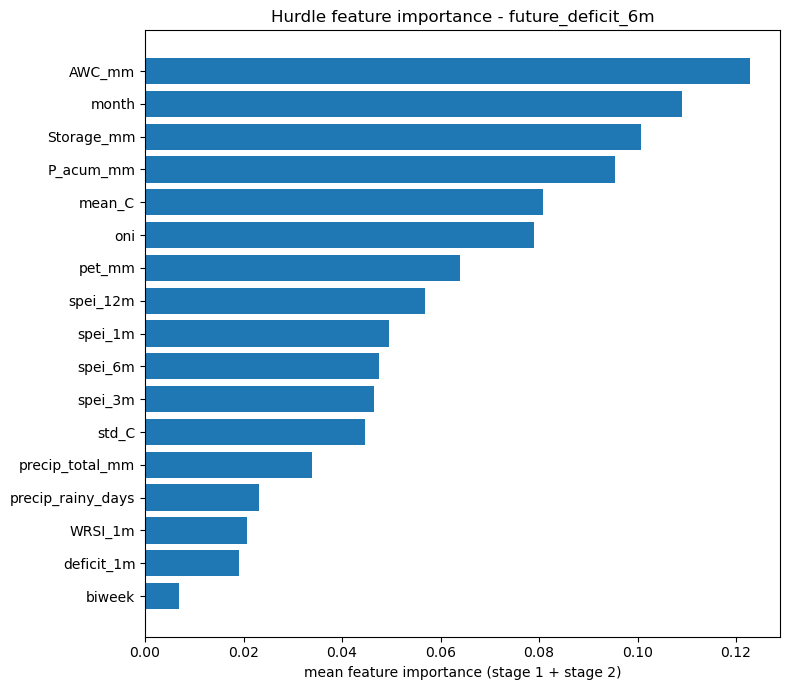

In [19]:
# Fit both stages once more on the full training data (6-month horizon).
target = "future_deficit_6m"
ytr = tr[target].to_numpy()
Xtr_all = tr[FEATURES].to_numpy()

# Stage 1
clf = make_classifier()
clf.fit(Xtr_all, (ytr > DEFICIT_THRESHOLD).astype(int))

# Stage 2 (positive rows only)
pos = ytr > DEFICIT_THRESHOLD
reg = make_regressor()
reg.fit(Xtr_all[pos], ytr[pos], sample_weight=weight_linear(ytr[pos]))

imp = pd.DataFrame({
    "stage1_clf": clf.feature_importances_,
    "stage2_reg": reg.feature_importances_,
}, index=FEATURES)
imp["mean"] = imp.mean(axis=1)
imp = imp.sort_values("mean", ascending=False)

print(imp.round(4))

plt.figure(figsize=(8, 7))
plt.barh(imp.index[::-1], imp["mean"][::-1])
plt.xlabel("mean feature importance (stage 1 + stage 2)")
plt.title(f"Hurdle feature importance - {target}")
plt.tight_layout()
plt.show()


## 10. Recall improvement (cumulative, threshold sweep, direct classifier)

Three complementary views to see if we can lift the recall of the severe
classes:

- **A. Cumulative recall** (`>= MEDIUM`, `>= HIGH`): the decision-relevant
  metric, less strict than exact-class match.
- **B. Threshold sweep**: on the binary "needs significant irrigation"
  (`>= HIGH`) decision, sweep the alarm threshold on the worst gated deficit ->
  the recall / precision frontier.
- **C. Direct 4-class classifier**: train a classifier directly on the
  suggestion label (instead of regression -> classify) and compare.

In [20]:
# ---------------------------------------------------------------------------
# A. Cumulative recall (decision-relevant)
# ---------------------------------------------------------------------------
def cumulative_recall(true_sugg, pred_sugg, min_level):
    """Recall of severity >= min_level (e.g. 'HIGH' means HIGH or NOT_SUITABLE)."""
    t = true_sugg.map(SEVERITY)
    p = pred_sugg.map(SEVERITY)
    m = t >= SEVERITY[min_level]
    return (p[m] >= SEVERITY[min_level]).mean()


print("Cumulative recall (>= level):")
for level in ["MEDIUM", "HIGH", "NOT_SUITABLE"]:
    b = cumulative_recall(true_sugg, base_sugg, level)
    g = cumulative_recall(true_sugg, gated_sugg, level)
    print(f"  >= {level:<13}: baseline={b:.3f}   hurdle(gated)={g:.3f}")

Cumulative recall (>= level):
  >= MEDIUM       : baseline=0.960   hurdle(gated)=0.914
  >= HIGH         : baseline=0.744   hurdle(gated)=0.735
  >= NOT_SUITABLE : baseline=0.674   hurdle(gated)=0.674


 threshold  recall_>=HIGH  precision_>=HIGH  false_alarms
        15          0.967             0.607          2301
        20          0.930             0.688          1548
        25          0.845             0.774           906
        30          0.735             0.845           497
        35          0.630             0.893           277
        40          0.532             0.921           167
        45          0.450             0.948            91


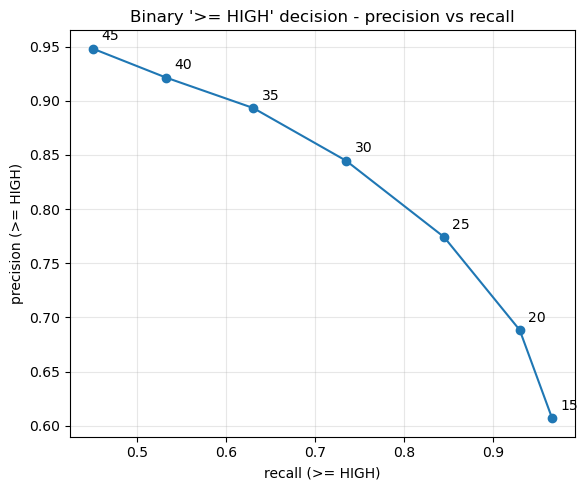

In [21]:
# ---------------------------------------------------------------------------
# B. Recall vs precision for the binary ">= HIGH" decision
# ---------------------------------------------------------------------------
# Severity is driven by the WORST gated deficit across the 3 horizons.
gated_worst = np.maximum(np.maximum(gated_preds[TARGETS[0]], gated_preds[TARGETS[1]]),
                         gated_preds[TARGETS[2]])

true_sev = true_sugg.map(SEVERITY)
y_high = (true_sev >= SEVERITY["HIGH"]).to_numpy()   # true ">= HIGH"

rows = []
for thr in [15, 20, 25, 30, 35, 40, 45]:
    pred_high = (gated_worst >= thr)
    tp = int((pred_high & y_high).sum())
    fp = int((pred_high & ~y_high).sum())
    fn = int((~pred_high & y_high).sum())
    recall = tp / (tp + fn) if (tp + fn) else float("nan")
    prec = tp / (tp + fp) if (tp + fp) else float("nan")
    rows.append([thr, recall, prec, fp])

sw = pd.DataFrame(rows, columns=["threshold", "recall_>=HIGH", "precision_>=HIGH", "false_alarms"])
print(sw.round(3).to_string(index=False))

# Frontier plot (label = alarm threshold on the worst gated deficit).
plt.figure(figsize=(6, 5))
plt.plot(sw["recall_>=HIGH"], sw["precision_>=HIGH"], "o-")
for _, r in sw.iterrows():
    plt.annotate(f"{r['threshold']:.0f}", (r["recall_>=HIGH"], r["precision_>=HIGH"]),
                 textcoords="offset points", xytext=(6, 6))
plt.xlabel("recall (>= HIGH)")
plt.ylabel("precision (>= HIGH)")
plt.title("Binary '>= HIGH' decision - precision vs recall")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# ---------------------------------------------------------------------------
# C. Direct 4-class classifier (instead of regression -> classify)
# ---------------------------------------------------------------------------
tr_sugg = to_suggestion(tr, {t: tr[t].to_numpy() for t in TARGETS})

clf4 = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=1,
                              class_weight="balanced", random_state=42, n_jobs=-1)
clf4.fit(Xtr_all, tr_sugg)
pred4 = pd.Series(clf4.predict(Xte_all), index=te.index)

print("Exact-class recall (holdout):")
for cls in ["MEDIUM", "HIGH", "NOT_SUITABLE"]:
    mask = true_sugg == cls
    g = (gated_sugg[mask] == cls).mean()
    d = (pred4[mask] == cls).mean()
    p_mask = pred4 == cls
    d_prec = (true_sugg[p_mask] == cls).mean() if p_mask.sum() else float("nan")
    print(f"  recall {cls:<13}: hurdle(gated)={g:.3f}   direct4class={d:.3f}"
          f"   (direct precision={d_prec:.3f})")

Exact-class recall (holdout):
  recall MEDIUM       : hurdle(gated)=0.610   direct4class=0.279   (direct precision=0.720)
  recall HIGH         : hurdle(gated)=0.456   direct4class=0.454   (direct precision=0.755)
  recall NOT_SUITABLE : hurdle(gated)=0.674   direct4class=0.833   (direct precision=0.838)


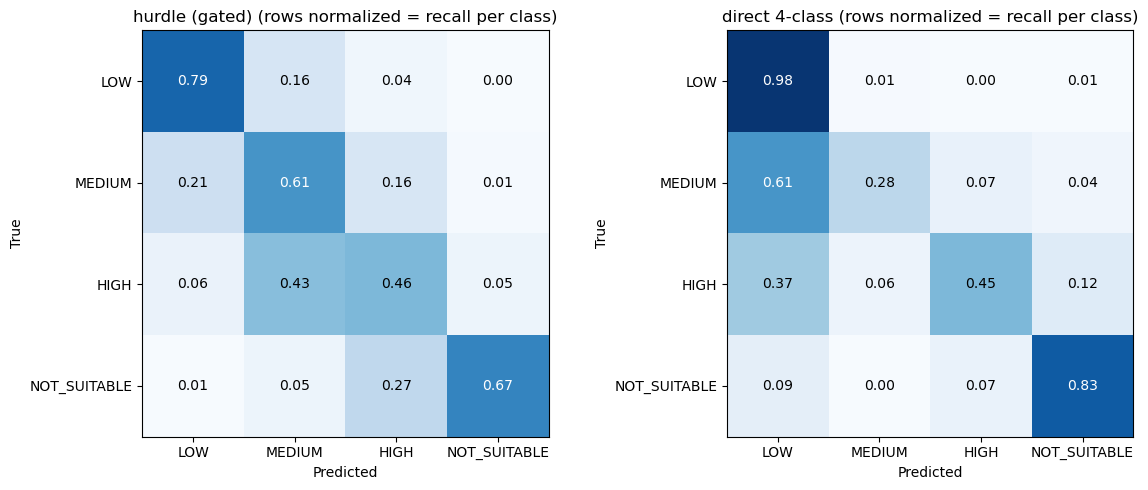

In [23]:
# ---------------------------------------------------------------------------
# Confusion matrices (4 classes, row-normalized = recall per class)
# ---------------------------------------------------------------------------
from sklearn.metrics import confusion_matrix

LABELS = ["LOW", "MEDIUM", "HIGH", "NOT_SUITABLE"]


def norm_confusion(true, pred):
    cm = confusion_matrix(true, pred, labels=LABELS)
    row_sums = cm.sum(axis=1, keepdims=True)
    return cm / np.where(row_sums == 0, 1, row_sums)


cm_g = norm_confusion(true_sugg, gated_sugg)
cm_d = norm_confusion(true_sugg, pred4)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title in [(axes[0], cm_g, "hurdle (gated)"),
                      (axes[1], cm_d, "direct 4-class")]:
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(4)); ax.set_xticklabels(LABELS)
    ax.set_yticks(range(4)); ax.set_yticklabels(LABELS)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title + " (rows normalized = recall per class)")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                    color="white" if cm[i, j] > 0.5 else "black")
plt.tight_layout()
plt.show()


## Summary

- The hurdle separates **"will there be a deficit?"** (stage 1) from
  **"how much?"** (stage 2); stage 1 (AUC ~0.91-0.98) nails the zero rows,
  which is why the hurdle MAE is far below the single RF.
- But `expected = P(deficit>0) * magnitude` **shrinks** the magnitude and
  downgrades the severe classes, so the naive hurdle loses recall of
  HIGH / NOT_SUITABLE.
- The decision-correct combination is the **gate**: keep the FULL stage-2
  magnitude when stage 1 says there is a deficit, else 0 (section 6).
- Adopt the hurdle if `hurdle(gated)` restores (or beats) the baseline recall
  of HIGH / NOT_SUITABLE while keeping the much lower MAE.
